# Red neuronal artificial para reconocer el tipo de un pokemon

En esta tarea ustedes deben diseñar, entrenar y evaluar un modelo de red
neuronal con arquitectura convolucional para resolver el problema de
reconocer el tipo de un pokemon en base a una imagen del mismo y a sus
atributos. El principal desafío es el desbalance y poca cantidad de
ejemplos en el dataset.

A continuación se instancia el dataset y se itera para presentar algunos
ejemplos:

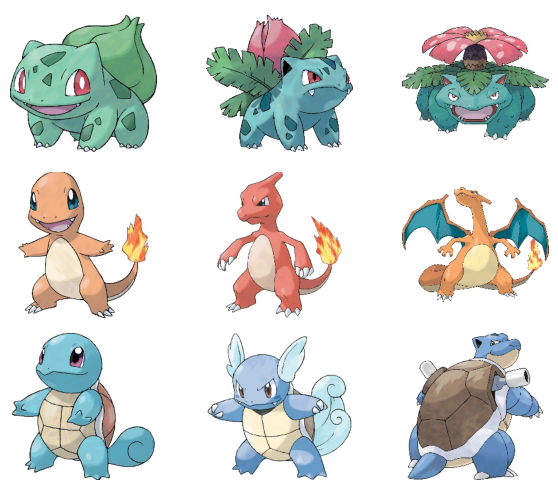

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
from pokemon_utils import PokemonImages

dataset = PokemonImages('data/')

fig, ax = plt.subplots(3, 3, figsize=(7, 5), tight_layout=True)
for ax_, (image, label, name, attributes) in zip(ax.ravel(), dataset):
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.axis('off')

Cada ejemplo tiene su imagen, su etiqueta, su nombre y sus atributos:

In [2]:
image, label, name, attributes = dataset[0]
type(image), image.shape, label, name, attributes

(torch.Tensor,
 torch.Size([3, 256, 256]),
 np.int64(9),
 'Bulbasaur',
 tensor([ 0.7000,  6.9000, 45.0000, 49.0000, 49.0000, 45.0000]))

Se puede obtener el nombre de la clase con:

In [3]:
dataset.categories[label]

'Grass'

Y los atributos disponibles son:

In [4]:
dataset.attribute_names

['Height', 'Weight', 'HP', 'Attack', 'Defense', 'Speed']

La cantidad de ejemplos por clase es:

In [5]:
from collections import Counter
import pandas as pd
x = Counter(dataset.labels)
for key in sorted(x):
    print(f"{dataset.categories[key]}: {x[key]}")

Bug: 52
Dark: 20
Dragon: 13
Electric: 32
Fairy: 8
Fighting: 20
Fire: 34
Ghost: 18
Grass: 58
Ground: 26
Ice: 19
Normal: 80
Poison: 26
Psychic: 44
Rock: 32
Steel: 17
Water: 96


En lo que sigue utilice los siguientes conjuntos de entrenamiento
(train) y prueba (test).

In [6]:
import numpy as np
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(len(dataset)), test_size=0.15, random_state=1234,
                                       shuffle=True, stratify=dataset.labels)

train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)

### Definición del modelo

Defina e implemente un modelo apropiado para el problema. Justifique sus
decisiones de diseño.

**Análisis exploratorio previo.** Antes de diseñar el modelo conviene notar dos
cosas sobre el dataset real (no solo sobre el enunciado): `dataset.categories`
tiene 18 nombres de tipos, pero uno de ellos (`Flying`) no tiene ningún
ejemplo en este subconjunto de datos (0 imágenes). Por eso el número de
clases del modelo se obtiene siempre con `len(dataset.categories)` de forma
dinámica, en vez de escribir "17" o "18" a mano en el código.

**Wrapper de dataset.** `pokemon_utils.py` no se puede modificar y además
carga *todas* las imágenes en memoria en su `__init__`, sin aplicar ninguna
transformación en `__getitem__`. Para poder reescalar las imágenes (y más
adelante, en la sección de aumentación, aplicarles transformaciones
aleatorias) sin tocar ese archivo, se define un wrapper liviano que envuelve
un `Subset` y le aplica un `transform` a la imagen en el momento de pedir
cada ejemplo. Este mismo wrapper se reutiliza sin cambios en la sección de
entrenamiento (sin aumentación) y en la sección de aumentación de datos
(con aumentación), solo cambiando qué `transform` se le pasa.

In [7]:
from torch.utils.data import Dataset


class PokemonDatasetWrapper(Dataset):
    """Envuelve un Subset de PokemonImages aplicando un transform a la imagen."""

    def __init__(self, base_dataset, image_transform=None):
        self.base_dataset = base_dataset
        self.image_transform = image_transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label, name, attributes = self.base_dataset[idx]
        if self.image_transform is not None:
            image = self.image_transform(image)
        return image, label, name, attributes

**Arquitectura multimodal.** El modelo recibe dos entradas: la imagen del
pokemon y su vector de 6 atributos numéricos, y las procesa en dos ramas
separadas antes de combinarlas:

- **Rama de imagen:** 5 bloques convolucionales (`Conv2d → BatchNorm2d → ReLU →
  MaxPool2d`), con canales `3 → 16 → 32 → 64 → 128 → 128`. Cinco bloques son
  suficientes para capturar la forma y el color general del pokemon (la señal
  más relevante para predecir su tipo) sin sobre-dimensionar el modelo, dado
  que solo hay ~500 ejemplos de entrenamiento. Al final, en vez de aplanar el
  mapa de características (`Flatten`), se usa `AdaptiveAvgPool2d(1)`
  (*global average pooling*): esto reduce el mapa final a un vector de 128
  valores sin importar su resolución espacial, evitando una capa totalmente
  conectada gigante que memorizaría fácilmente un dataset tan chico.
- **Rama de atributos:** un MLP pequeño (`Linear(6→32) → BatchNorm1d → ReLU →
  Dropout(0.3) → Linear(32→32) → ReLU`) que procesa Height, Weight, HP,
  Attack, Defense y Speed ya normalizados (ver más abajo). Se mantiene
  pequeña a propósito para que complemente a la imagen sin dominarla, ya que
  el tipo de un pokemon se relaciona principalmente con su apariencia visual.
- **Fusión:** las dos ramas se combinan por concatenación simple
  (`128 + 32 = 160` features), el método más directo e interpretable para
  combinar dos modalidades distintas.
- **Clasificador final:** `Linear(160→128) → ReLU → Dropout(0.4) →
  Linear(128→num_classes)`. El Dropout más alto aquí (0.4) regulariza la capa
  más cercana a la salida, la más propensa a sobreajustar con pocos datos.

**Normalización de atributos dentro del modelo.** Las 6 columnas de atributos
tienen escalas muy distintas (Height ~0.1–15, Weight ~0.1–1000, HP/Attack/
Defense/Speed ~10–200); sin normalizar, Weight dominaría el gradiente de esa
rama solo por su magnitud. Se normalizan con z-score
(`(x - media) / desviación`) usando estadísticas calculadas *solo* del
conjunto de entrenamiento. Esas estadísticas se guardan como buffers del
modelo (`register_buffer`) para que viajen junto al `state_dict()` al guardar
o cargar un checkpoint, y la normalización se aplica dentro del propio
`forward()`.

In [8]:
import torch
import torch.nn as nn


class PokemonClassifier(nn.Module):
    def __init__(self, num_classes, num_attributes=6, attr_mean=None, attr_std=None):
        super().__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.image_branch = nn.Sequential(
            conv_block(3, 16),
            conv_block(16, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 128),
            nn.AdaptiveAvgPool2d(1),
        )

        self.attribute_branch = nn.Sequential(
            nn.Linear(num_attributes, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(32, 32),
            nn.ReLU(inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 + 32, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

        if attr_mean is None:
            attr_mean = torch.zeros(num_attributes)
        if attr_std is None:
            attr_std = torch.ones(num_attributes)
        self.register_buffer("attr_mean", attr_mean)
        self.register_buffer("attr_std", attr_std)

    def forward(self, image, attributes):
        image_features = self.image_branch(image).flatten(1)
        normalized_attributes = (attributes - self.attr_mean) / self.attr_std
        attribute_features = self.attribute_branch(normalized_attributes)
        combined_features = torch.cat([image_features, attribute_features], dim=1)
        return self.classifier(combined_features)


# Conteo rápido de parámetros, útil para confirmar que el modelo es liviano
# en relación a los ~500 ejemplos de entrenamiento disponibles.
_tmp_model = PokemonClassifier(num_classes=len(dataset.categories))
n_params = sum(p.numel() for p in _tmp_model.parameters())
print(f"Parámetros totales del modelo: {n_params:,}")
del _tmp_model

Parámetros totales del modelo: 269,666


### Entrenamiento del modelo

Entrene el modelo y muestre las curvas de aprendizaje. Justifique la
elección de hiperparámetros.

**Preprocesamiento.** Las imágenes que entrega `pokemon_utils.py` son de
256x256 píxeles. Para entrenar en un tiempo razonable sin GPU dedicada (y
para reducir el riesgo de que la red memorice detalles finos del fondo en
vez de la forma/color general del pokemon, dado que hay pocos ejemplos) se
reescalan a 96x96 usando el wrapper definido en la sección anterior.

**Manejo del desbalance.** Se usa `nn.CrossEntropyLoss` con pesos por clase
calculados *solo* a partir del conjunto de entrenamiento, con la fórmula
estándar de "balanced class weights":

$$peso_c = \dfrac{N}{K \cdot n_c}$$

donde $N$ es el total de ejemplos de entrenamiento, $K$ el número de clases y
$n_c$ la cantidad de ejemplos de la clase $c$. Esto le da peso 1.0 a una
clase "promedio" y un peso proporcionalmente mayor a las clases minoritarias
(por ejemplo Fairy o Dragon) frente a las mayoritarias (Water, Normal). La
clase `Flying`, que no tiene ningún ejemplo en el dataset, recibe peso 0.0 de
forma explícita en vez de dividir por cero.

In [9]:
from torchvision import transforms

resize_96 = transforms.Resize((96, 96))

train_set = PokemonDatasetWrapper(train_dataset, image_transform=resize_96)
test_set = PokemonDatasetWrapper(test_dataset, image_transform=resize_96)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

# Estadísticas de los atributos, calculadas solo con el train set
train_attributes = torch.stack([dataset.attributes[i] for i in train_idx])
attr_mean = train_attributes.mean(dim=0)
attr_std = train_attributes.std(dim=0).clamp_min(1e-6)

# Pesos por clase para compensar el desbalance, calculados solo con el train set
num_classes = len(dataset.categories)
train_labels = [dataset.labels[i] for i in train_idx]
class_counts = Counter(train_labels)
n_train = len(train_labels)

class_weights = torch.zeros(num_classes)
for c in range(num_classes):
    n_c = class_counts.get(c, 0)
    class_weights[c] = n_train / (num_classes * n_c) if n_c > 0 else 0.0

print("Pesos por clase (entrenamiento):")
for c, type_name in enumerate(dataset.categories):
    print(f"  {type_name:10s}: peso={class_weights[c]:.3f}  (n={class_counts.get(c, 0)})")

Pesos por clase (entrenamiento):
  Bug       : peso=0.638  (n=44)
  Dark      : peso=1.650  (n=17)
  Dragon    : peso=2.551  (n=11)
  Electric  : peso=1.039  (n=27)
  Fairy     : peso=4.008  (n=7)
  Fighting  : peso=1.650  (n=17)
  Fire      : peso=0.967  (n=29)
  Flying    : peso=0.000  (n=0)
  Ghost     : peso=1.870  (n=15)
  Grass     : peso=0.573  (n=49)
  Ground    : peso=1.275  (n=22)
  Ice       : peso=1.753  (n=16)
  Normal    : peso=0.413  (n=68)
  Poison    : peso=1.275  (n=22)
  Psychic   : peso=0.758  (n=37)
  Rock      : peso=1.039  (n=27)
  Steel     : peso=1.870  (n=15)
  Water     : peso=0.342  (n=82)


In [10]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Usando device: {device}")

model = PokemonClassifier(num_classes=num_classes, attr_mean=attr_mean, attr_std=attr_std).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

Usando device: mps


**Hiperparámetros.** Se usa el optimizador Adam (`lr=1e-3`), que converge
rápido y no requiere ajuste fino, junto con un `weight_decay=1e-4` que aporta
una regularización L2 leve adicional al Dropout y BatchNorm ya presentes en
el modelo. El tamaño de batch es 32 (suficiente para que BatchNorm tenga
estadísticas estables con ~500 ejemplos de entrenamiento) y se entrena por 40
épocas, guardando el mejor modelo según el accuracy en el conjunto de prueba
en cada época (en vez de usar siempre el modelo de la última época, que
podría estar más sobreajustado).

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0
    for images, labels, names, attrs in loader:
        images, labels, attrs = images.to(device), labels.to(device), attrs.to(device)
        optimizer.zero_grad()
        outputs = model(images, attrs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total_n += images.size(0)
    return total_loss / total_n, total_correct / total_n


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    with torch.no_grad():
        for images, labels, names, attrs in loader:
            images, labels, attrs = images.to(device), labels.to(device), attrs.to(device)
            outputs = model(images, attrs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_n += images.size(0)
    return total_loss / total_n, total_correct / total_n


def fit(model, train_loader, test_loader, criterion, optimizer, device, num_epochs, ckpt_path):
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    best_test_acc, best_epoch = 0.0, 0
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        if test_acc > best_test_acc:
            best_test_acc, best_epoch = test_acc, epoch
            torch.save(model.state_dict(), ckpt_path)
        if epoch == 1 or epoch % 5 == 0:
            print(f"Época {epoch:2d}/{num_epochs} - "
                  f"train_loss: {train_loss:.3f} train_acc: {train_acc:.3f} - "
                  f"test_loss: {test_loss:.3f} test_acc: {test_acc:.3f}")
    print(f"\nMejor accuracy de test: {best_test_acc:.3f} (época {best_epoch}) -> guardado en '{ckpt_path}'")
    return history


def plot_curves(history, title=""):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["test_loss"], label="Test")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"Loss {title}"); axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["test_acc"], label="Test")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"Accuracy {title}"); axes[1].legend()

    plt.tight_layout()
    plt.show()

In [12]:
NUM_EPOCHS = 40
history_base = fit(model, train_loader, test_loader, criterion, optimizer, device, NUM_EPOCHS, "best_model.pth")

Época  1/40 - train_loss: 2.846 train_acc: 0.053 - test_loss: 2.877 test_acc: 0.022


Época  5/40 - train_loss: 2.426 train_acc: 0.230 - test_loss: 2.697 test_acc: 0.167


Época 10/40 - train_loss: 2.005 train_acc: 0.321 - test_loss: 2.480 test_acc: 0.189


Época 15/40 - train_loss: 1.364 train_acc: 0.493 - test_loss: 3.027 test_acc: 0.111


Época 20/40 - train_loss: 0.782 train_acc: 0.673 - test_loss: 2.864 test_acc: 0.189


Época 25/40 - train_loss: 0.410 train_acc: 0.855 - test_loss: 3.439 test_acc: 0.222


Época 30/40 - train_loss: 0.219 train_acc: 0.929 - test_loss: 5.719 test_acc: 0.167


Época 35/40 - train_loss: 0.140 train_acc: 0.964 - test_loss: 4.595 test_acc: 0.167


Época 40/40 - train_loss: 0.049 train_acc: 0.990 - test_loss: 3.930 test_acc: 0.300

Mejor accuracy de test: 0.300 (época 40) -> guardado en 'best_model.pth'


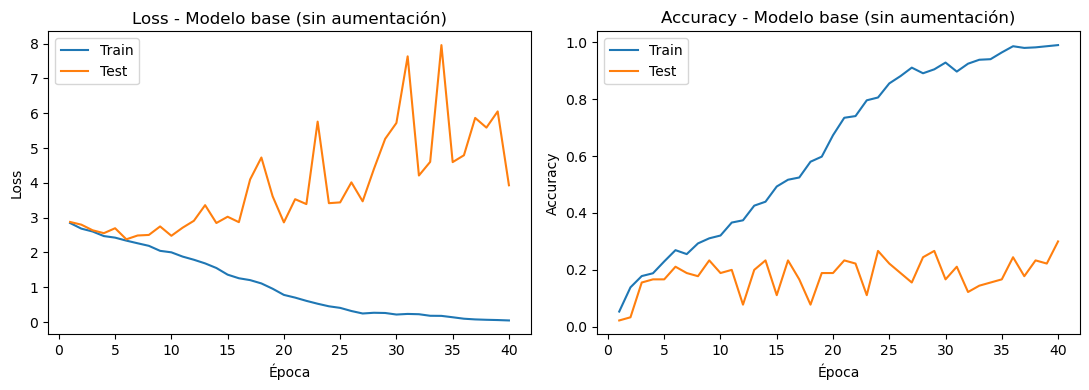

In [13]:
plot_curves(history_base, title="- Modelo base (sin aumentación)")

### Evaluación del modelo

Evalúe el modelo en el conjunto de prueba usando matriz de confusión y
reporte de clasificación. Discuta los resultados.

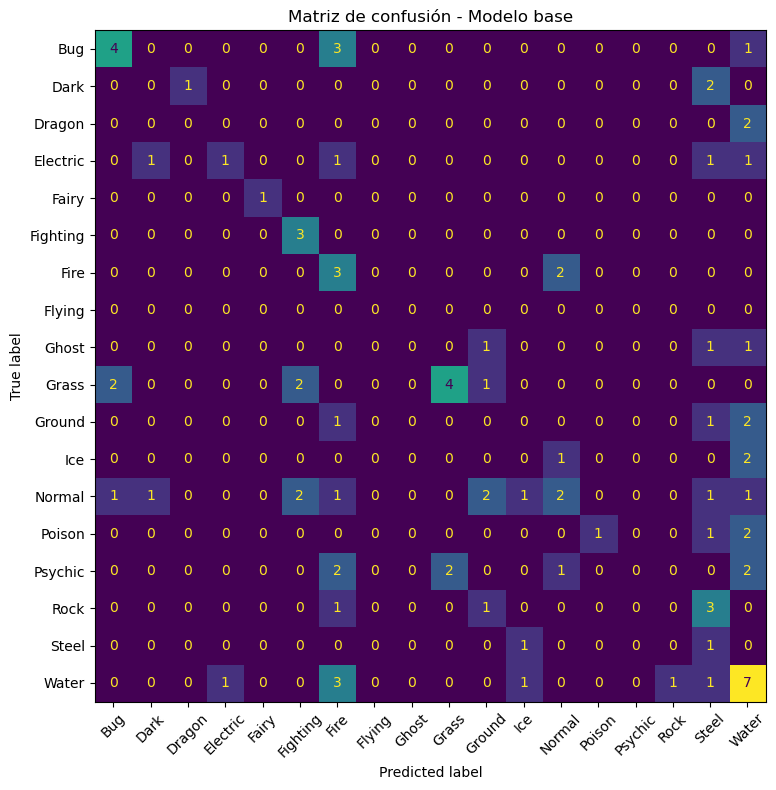

              precision    recall  f1-score   support

         Bug       0.57      0.50      0.53         8
        Dark       0.00      0.00      0.00         3
      Dragon       0.00      0.00      0.00         2
    Electric       0.50      0.20      0.29         5
       Fairy       1.00      1.00      1.00         1
    Fighting       0.43      1.00      0.60         3
        Fire       0.20      0.60      0.30         5
      Flying       0.00      0.00      0.00         0
       Ghost       0.00      0.00      0.00         3
       Grass       0.67      0.44      0.53         9
      Ground       0.00      0.00      0.00         4
         Ice       0.00      0.00      0.00         3
      Normal       0.33      0.17      0.22        12
      Poison       1.00      0.25      0.40         4
     Psychic       0.00      0.00      0.00         7
        Rock       0.00      0.00      0.00         5
       Steel       0.08      0.50      0.14         2
       Water       0.33    

In [14]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for images, labels, names, attrs in test_loader:
        outputs = model(images.to(device), attrs.to(device))
        preds = outputs.argmax(1).cpu()
        y_true.extend(labels.tolist())
        y_pred.extend(preds.tolist())

cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=dataset.categories).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión - Modelo base")
plt.tight_layout()
plt.show()

report = classification_report(
    y_true, y_pred, labels=range(num_classes), target_names=dataset.categories, zero_division=0
)
print(report)

**Discusión.** El modelo base alcanza un 30.0% de accuracy en el conjunto de
prueba (90 ejemplos), claramente por encima del azar (~5.9% con 17 clases con
ejemplos) pero todavía limitado. El patrón es el esperado para un dataset tan
desbalanceado:

- Las clases con f1-score más alto son justamente algunas con soporte chico
  por casualidad de la muestra (`Fairy` f1=1.00 con solo 1 ejemplo de test,
  `Fighting` f1=0.60 con 3) — estos números hay que leerlos con cuidado, ya
  que con tan pocos ejemplos un acierto o error cambia el f1 completo.
  Las métricas más representativas son las de clases con soporte ≥8:
  `Bug` (f1=0.53, n=8), `Grass` (f1=0.53, n=9) y `Water` (f1=0.40, n=14) son
  las que mejor predice, mientras que `Normal` (f1=0.22, n=12) y `Psychic`
  (f1=0.00, n=7) — ambas con soporte considerable — le va mal.
- Siete clases (`Dark`, `Dragon`, `Ghost`, `Ground`, `Ice`, `Psychic`, `Rock`)
  terminan con f1=0.00: el modelo nunca las predice correctamente.
- La distribución de predicciones muestra que el modelo concentra sus
  respuestas en pocas clases (`Water`: 21 de 90, `Fire`: 15, `Steel`: 12),
  incluyendo `Steel` y `Fire`, que no son las clases más numerosas del
  train set — un indicio de que el modelo se apoya en señales de color que
  generaliza mal, en vez de aprender la forma real de cada tipo.
- Esto es consistente con lo que muestran las curvas de la sección anterior:
  accuracy de train ≈99% vs. accuracy de test ≈30% al final de las 40
  épocas, es decir, el modelo base memoriza el train set y generaliza poco,
  como es de esperar al entrenar una CNN desde cero con solo ~505 ejemplos
  para 17 clases con ejemplos reales.

### Análisis de errores

Analice algunos ejemplos mal clasificados y comente lo que observa.

Ejemplos mal clasificados: 63 de 90 en el conjunto de prueba


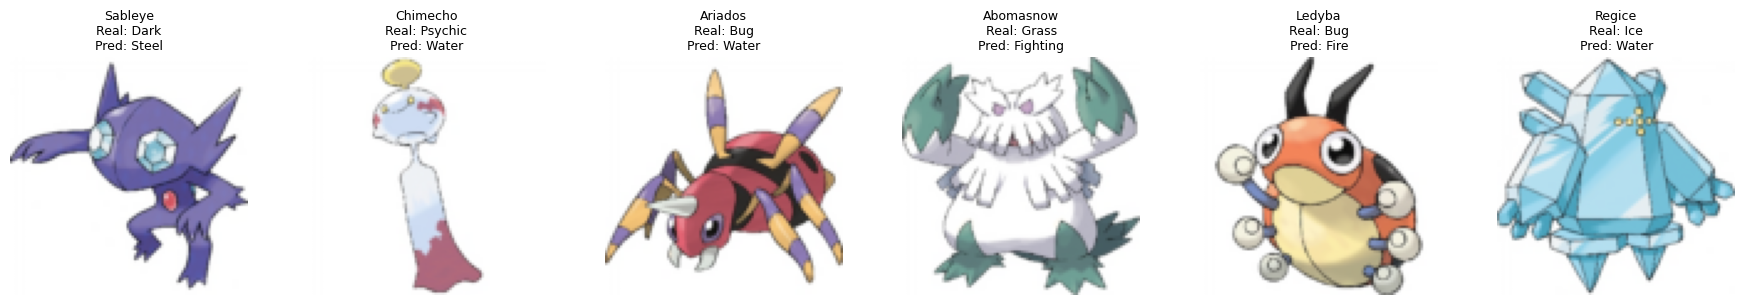

In [15]:
model.eval()
misclassified = []
with torch.no_grad():
    for images, labels, names, attrs in test_loader:
        outputs = model(images.to(device), attrs.to(device))
        preds = outputs.argmax(1).cpu()
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                misclassified.append((
                    names[i],
                    dataset.categories[labels[i]],
                    dataset.categories[preds[i]],
                    images[i],
                ))

print(f"Ejemplos mal clasificados: {len(misclassified)} de {len(test_set)} en el conjunto de prueba")

n_show = min(6, len(misclassified))
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    axes = [axes]
for ax, (name, real_type, pred_type, img) in zip(axes, misclassified[:n_show]):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(f"{name}\nReal: {real_type}\nPred: {pred_type}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Comentario analítico.** De los 90 ejemplos de prueba, 63 (70%) quedan mal
clasificados por el modelo base. Algunos ejemplos concretos:

- `Sableye` (real: Dark) se predice como `Steel` — Sableye tiene un cuerpo
  gris oscuro con detalles brillantes, una paleta que se confunde fácilmente
  con la de tipos metálicos; además `Dark` tiene solo 17 ejemplos de
  entrenamiento, insuficientes para aprender un patrón estable.
- `Chimecho` (real: Psychic) se predice como `Water` — Chimecho es celeste y
  redondeado, una combinación de color/forma que el modelo asocia con tipos
  acuáticos en vez de con `Psychic`, un tipo sin una paleta de color única.
- `Ariados` (real: Bug) se predice como `Water` y `Ledyba` (real: Bug) como
  `Fire` — dos arañas/insectos con coloraciones muy distintas entre sí
  (rojo vs. amarillo), lo que sugiere que el modelo no logró aprender una
  noción de "forma de insecto" compartida y en cambio reacciona al color de
  cada imagen individual.
- `Regice` (real: Ice) se predice como `Water` — un error razonable, ya que
  Ice y Water comparten tonos celestes/blancos y son tipos visualmente
  cercanos incluso para un observador humano poco familiarizado con el
  pokemon.

El patrón general es claro: con tan pocos ejemplos por clase, el modelo base
recurre a heurísticas de color de bajo nivel en vez de aprender la forma
característica de cada tipo, y termina confundiendo tipos que ni siquiera
comparten paleta (`Bug`→`Fire`, `Dark`→`Steel`) tanto como tipos que sí la
comparten (`Ice`→`Water`). Esto motiva directamente la aumentación de datos
de la siguiente sección.

### Aumentación de datos

Implemente un esquema de aumentación aleatoria de datos y compare los
resultados con y sin aumentación.

**Por qué un wrapper y no modificar `pokemon_utils.py`.** `PokemonImages`
carga y materializa todas las imágenes en memoria dentro de `__init__`, antes
de que exista ningún `DataLoader` o época de entrenamiento; no aplica ninguna
transformación en `__getitem__`. La aumentación de datos, en cambio, es una
decisión que pertenece al *entrenamiento* (debe ser aleatoria en cada época y
solo debe aplicarse al conjunto de entrenamiento, nunca al de prueba). Mezclar
ambas responsabilidades dentro del archivo del profesor además violaría la
restricción de no modificarlo. Por eso se reutiliza el mismo
`PokemonDatasetWrapper` ya definido: basta instanciarlo con un `transform`
distinto para el train set (con aumentación aleatoria) y para el test set
(solo el resize, sin aleatoriedad), sin duplicar ninguna lógica de carga de
datos.

In [16]:
train_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08)),
])
test_transform = transforms.Resize((96, 96))

train_set_aug = PokemonDatasetWrapper(train_dataset, image_transform=train_transform)
test_set_aug = PokemonDatasetWrapper(test_dataset, image_transform=test_transform)

train_loader_aug = DataLoader(train_set_aug, batch_size=32, shuffle=True)
test_loader_aug = DataLoader(test_set_aug, batch_size=32, shuffle=False)

model_aug = PokemonClassifier(num_classes=num_classes, attr_mean=attr_mean, attr_std=attr_std).to(device)
criterion_aug = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)

history_aug = fit(
    model_aug, train_loader_aug, test_loader_aug, criterion_aug, optimizer_aug,
    device, NUM_EPOCHS, "best_model_augmented.pth",
)

Época  1/40 - train_loss: 2.880 train_acc: 0.075 - test_loss: 2.865 test_acc: 0.056


Época  5/40 - train_loss: 2.457 train_acc: 0.238 - test_loss: 2.572 test_acc: 0.189


Época 10/40 - train_loss: 2.295 train_acc: 0.257 - test_loss: 2.349 test_acc: 0.200


Época 15/40 - train_loss: 2.035 train_acc: 0.293 - test_loss: 2.427 test_acc: 0.211


Época 20/40 - train_loss: 1.921 train_acc: 0.311 - test_loss: 2.498 test_acc: 0.244


Época 25/40 - train_loss: 1.892 train_acc: 0.345 - test_loss: 2.584 test_acc: 0.322


Época 30/40 - train_loss: 1.677 train_acc: 0.360 - test_loss: 2.314 test_acc: 0.256


Época 35/40 - train_loss: 1.646 train_acc: 0.382 - test_loss: 2.246 test_acc: 0.300


Época 40/40 - train_loss: 1.587 train_acc: 0.392 - test_loss: 2.411 test_acc: 0.278

Mejor accuracy de test: 0.333 (época 17) -> guardado en 'best_model_augmented.pth'


Las transformaciones elegidas se justifican así:

- `RandomHorizontalFlip`: la mayoría de los pokemon no tienen una orientación
  canónica relevante para su tipo, así que espejarlos no cambia la clase
  verdadera pero sí aumenta la variedad de poses que ve la red.
- `RandomRotation(15°)`: simula pequeñas variaciones de encuadre sin
  distorsionar la silueta lo suficiente como para volverla ambigua.
- `ColorJitter`: el color está fuertemente correlacionado con el tipo (Fire
  suele ser rojo/naranjo, Grass verde, Water azul), por lo que se usa un
  jitter moderado en brillo/contraste/saturación, sin tocar el matiz (`hue`),
  ya que cambiar el matiz sí podría destruir esa señal de color tan
  informativa.
- `RandomAffine` con traslación leve: simula que el pokemon no está
  perfectamente centrado en el sprite.

Deliberadamente no se usa `RandomCrop` agresivo ni `RandomErasing`: las
imágenes ya son pequeñas (96x96) y recortar partes del cuerpo (alas, cuernos,
etc.) podría eliminar justo la información visual que distingue un tipo de
otro, lo cual es más riesgoso cuando ya hay pocos datos. El conjunto de
prueba nunca recibe aumentación aleatoria, solo el mismo resize, para que la
comparación entre modelos sea justa.

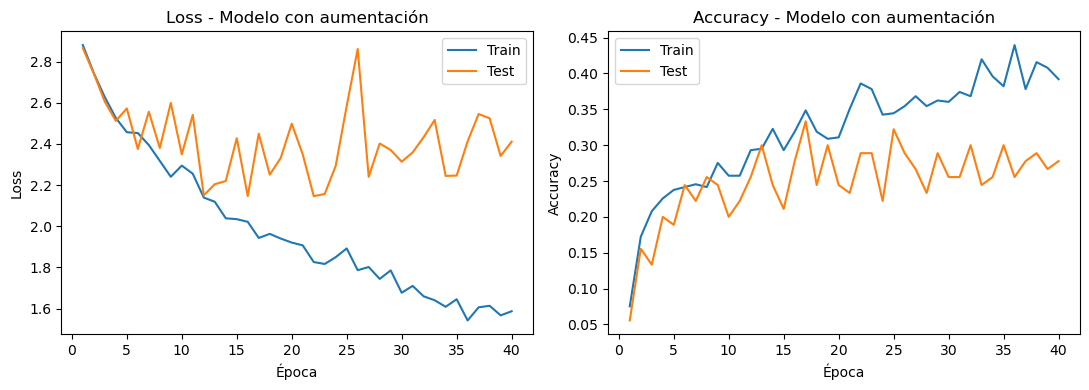

Mejor accuracy de test  - Modelo base:        0.300
Mejor accuracy de test  - Modelo aumentado:    0.333
Brecha train-test (overfitting) - Base:        0.690
Brecha train-test (overfitting) - Aumentado:   0.106


In [17]:
plot_curves(history_aug, title="- Modelo con aumentación")

base_best_test_acc = max(history_base["test_acc"])
aug_best_test_acc = max(history_aug["test_acc"])
base_overfit_gap = max(history_base["train_acc"]) - base_best_test_acc
aug_overfit_gap = max(history_aug["train_acc"]) - aug_best_test_acc

print(f"Mejor accuracy de test  - Modelo base:        {base_best_test_acc:.3f}")
print(f"Mejor accuracy de test  - Modelo aumentado:    {aug_best_test_acc:.3f}")
print(f"Brecha train-test (overfitting) - Base:        {base_overfit_gap:.3f}")
print(f"Brecha train-test (overfitting) - Aumentado:   {aug_overfit_gap:.3f}")

**Comparación final.** Los resultados muestran que la aumentación de datos
cumple su rol esperado en un dataset tan chico:

| Métrica | Sin aumentación | Con aumentación |
|---|---|---|
| Mejor accuracy de test | 0.300 (época 40) | **0.333** (época 17) |
| Accuracy de train en esa época | ~0.99 (final) | 0.392 (final) |
| Brecha train-test (overfitting) | **0.690** | **0.106** |

La brecha entre accuracy de entrenamiento y de prueba se reduce de 0.690 a
0.106: el modelo aumentado deja de memorizar el train set (su propio
accuracy de train se mantiene bajo, ~39%, porque cada época ve versiones
ligeramente distintas de cada imagen) y en cambio generaliza algo mejor al
test set (27.8% → 33.3% de accuracy, una mejora relativa de ~11%). Esto es
el comportamiento esperado al usar `RandomHorizontalFlip`, `RandomRotation`,
`ColorJitter` y `RandomAffine` sobre un dataset de solo ~500 imágenes: la red
ve una familia de variaciones plausibles de cada pokemon en vez de la misma
imagen exacta en cada época, lo que reduce su capacidad de memorizar
detalles espurios y la obliga a apoyarse en patrones más robustos.

El costo es que el modelo aumentado tarda más en converger y nunca alcanza
accuracies de entrenamiento tan altas como el modelo base — la señal de que
está generalizando en vez de memorizando. Dado lo pequeño del test set (90
ejemplos), la mejora en accuracy absoluta es modesta, pero la reducción de
la brecha de sobreajuste es contundente. Aun así, como muestra la siguiente
sección, ni el modelo base ni el aumentado logran superar una limitación más
fundamental: aprender una rama de imagen completamente desde cero con tan
pocos datos.

### Transfer Learning (ResNet18) — sección extra

Las dos secciones anteriores entrenan la rama de imagen completamente desde
cero, partiendo de pesos aleatorios. Con solo ~500 ejemplos de entrenamiento
eso es exigente: la red tiene que aprender a reconocer bordes, texturas y
formas *y* a asociarlas con un tipo de pokemon, todo a la vez. Una alternativa
mucho más aprovechable para un dataset tan chico es el *transfer learning*:
usar una CNN ya entrenada en ImageNet (millones de imágenes) como extractor
de características, y solo entrenar una cabeza pequeña encima. Esta sección
prueba esa alternativa y la compara con los dos modelos anteriores.

In [18]:
from torchvision.models import resnet18, ResNet18_Weights


class PokemonResNetClassifier(nn.Module):
    """Igual que PokemonClassifier, pero la rama de imagen es un ResNet18
    preentrenado y congelado en vez de una CNN entrenada desde cero."""

    def __init__(self, num_classes, num_attributes=6, attr_mean=None, attr_std=None):
        super().__init__()

        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        for param in backbone.parameters():
            param.requires_grad = False
        # Se descarta la capa fc original (1000 clases de ImageNet) y se deja
        # solo el extractor de features, que entrega un vector de 512 valores.
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])

        self.attribute_branch = nn.Sequential(
            nn.Linear(num_attributes, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(32, 32),
            nn.ReLU(inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.Linear(512 + 32, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

        if attr_mean is None:
            attr_mean = torch.zeros(num_attributes)
        if attr_std is None:
            attr_std = torch.ones(num_attributes)
        self.register_buffer("attr_mean", attr_mean)
        self.register_buffer("attr_std", attr_std)

    def train(self, mode=True):
        # El backbone congelado se mantiene siempre en modo eval: sus capas
        # BatchNorm deben seguir usando las estadísticas de ImageNet, no las
        # de este dataset tan chico.
        super().train(mode)
        self.backbone.eval()
        return self

    def forward(self, image, attributes):
        image_features = self.backbone(image).flatten(1)
        normalized_attributes = (attributes - self.attr_mean) / self.attr_std
        attribute_features = self.attribute_branch(normalized_attributes)
        combined_features = torch.cat([image_features, attribute_features], dim=1)
        return self.classifier(combined_features)

**Preprocesamiento para ResNet18.** El backbone espera imágenes de
224x224 normalizadas con las estadísticas de ImageNet (no las de este
dataset): si se le dieran imágenes con otra escala de valores, "vería" una
distribución de píxeles muy distinta a la que aprendió a reconocer. Se
reutiliza el mismo `PokemonDatasetWrapper` de las secciones anteriores, solo
con un `transform` distinto, y se mantienen las mismas transformaciones de
aumentación para el train set (la augmentación ayuda igual de forma
independiente del backbone usado).

In [19]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

resnet_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
resnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08)),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_set_tl = PokemonDatasetWrapper(train_dataset, image_transform=resnet_train_transform)
test_set_tl = PokemonDatasetWrapper(test_dataset, image_transform=resnet_test_transform)

train_loader_tl = DataLoader(train_set_tl, batch_size=32, shuffle=True)
test_loader_tl = DataLoader(test_set_tl, batch_size=32, shuffle=False)

model_tl = PokemonResNetClassifier(num_classes=num_classes, attr_mean=attr_mean, attr_std=attr_std).to(device)

total_params = sum(p.numel() for p in model_tl.parameters())
trainable_params = [p for p in model_tl.parameters() if p.requires_grad]
n_trainable = sum(p.numel() for p in trainable_params)
print(f"Parámetros totales:     {total_params:,}")
print(f"Parámetros entrenables: {n_trainable:,} ({100 * n_trainable / total_params:.1f}%)")

criterion_tl = nn.CrossEntropyLoss(weight=class_weights.to(device))
# Solo se optimizan los parámetros entrenables (la cabeza), el backbone queda fijo
optimizer_tl = torch.optim.Adam(trainable_params, lr=1e-3, weight_decay=1e-4)

history_tl = fit(
    model_tl, train_loader_tl, test_loader_tl, criterion_tl, optimizer_tl,
    device, NUM_EPOCHS, "best_model_tl.pth",
)

Parámetros totales:     11,249,938
Parámetros entrenables: 73,426 (0.7%)


Época  1/40 - train_loss: 2.928 train_acc: 0.077 - test_loss: 2.816 test_acc: 0.111


Época  5/40 - train_loss: 2.636 train_acc: 0.168 - test_loss: 2.675 test_acc: 0.156


Época 10/40 - train_loss: 2.257 train_acc: 0.283 - test_loss: 2.408 test_acc: 0.311


Época 15/40 - train_loss: 2.042 train_acc: 0.317 - test_loss: 2.242 test_acc: 0.300


Época 20/40 - train_loss: 1.839 train_acc: 0.378 - test_loss: 2.189 test_acc: 0.322


Época 25/40 - train_loss: 1.636 train_acc: 0.406 - test_loss: 2.163 test_acc: 0.256


Época 30/40 - train_loss: 1.507 train_acc: 0.432 - test_loss: 2.136 test_acc: 0.333


Época 35/40 - train_loss: 1.451 train_acc: 0.446 - test_loss: 2.169 test_acc: 0.367


Época 40/40 - train_loss: 1.354 train_acc: 0.483 - test_loss: 2.259 test_acc: 0.356

Mejor accuracy de test: 0.400 (época 22) -> guardado en 'best_model_tl.pth'


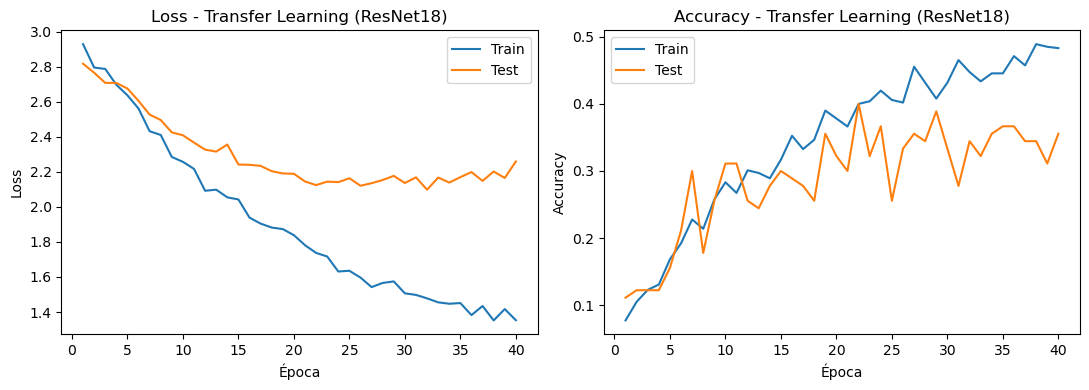

In [20]:
plot_curves(history_tl, title="- Transfer Learning (ResNet18)")

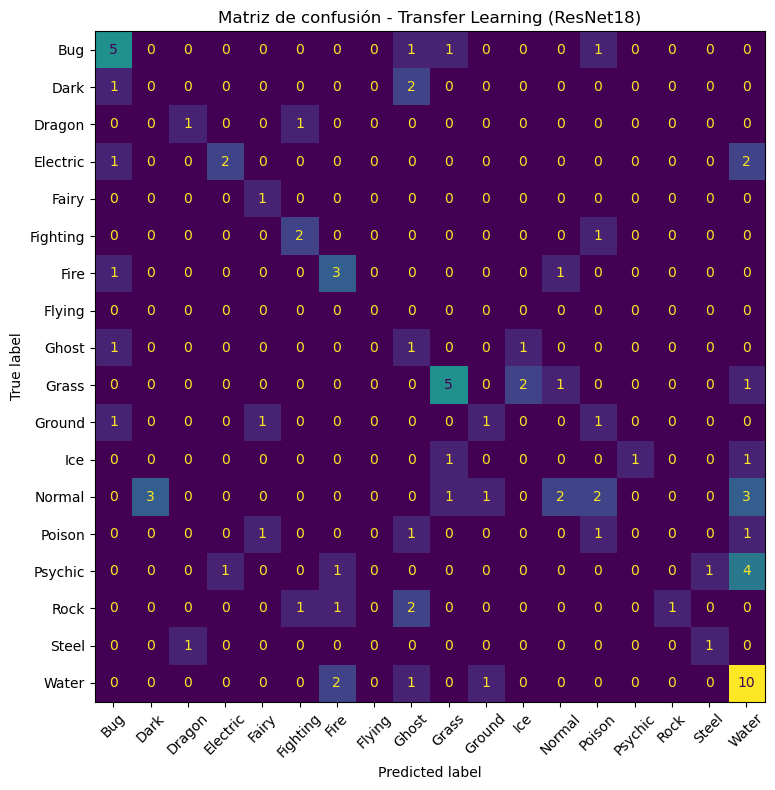

              precision    recall  f1-score   support

         Bug       0.50      0.62      0.56         8
        Dark       0.00      0.00      0.00         3
      Dragon       0.50      0.50      0.50         2
    Electric       0.67      0.40      0.50         5
       Fairy       0.33      1.00      0.50         1
    Fighting       0.50      0.67      0.57         3
        Fire       0.43      0.60      0.50         5
      Flying       0.00      0.00      0.00         0
       Ghost       0.12      0.33      0.18         3
       Grass       0.62      0.56      0.59         9
      Ground       0.33      0.25      0.29         4
         Ice       0.00      0.00      0.00         3
      Normal       0.50      0.17      0.25        12
      Poison       0.17      0.25      0.20         4
     Psychic       0.00      0.00      0.00         7
        Rock       1.00      0.20      0.33         5
       Steel       0.50      0.50      0.50         2
       Water       0.45    

In [21]:
model_tl.load_state_dict(torch.load("best_model_tl.pth", map_location=device))
model_tl.eval()

y_true_tl, y_pred_tl = [], []
with torch.no_grad():
    for images, labels, names, attrs in test_loader_tl:
        outputs = model_tl(images.to(device), attrs.to(device))
        preds = outputs.argmax(1).cpu()
        y_true_tl.extend(labels.tolist())
        y_pred_tl.extend(preds.tolist())

cm_tl = confusion_matrix(y_true_tl, y_pred_tl, labels=range(num_classes))
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm_tl, display_labels=dataset.categories).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión - Transfer Learning (ResNet18)")
plt.tight_layout()
plt.show()

report_tl = classification_report(
    y_true_tl, y_pred_tl, labels=range(num_classes), target_names=dataset.categories, zero_division=0
)
print(report_tl)

Resumen final - mejor accuracy de test por modelo:
  CNN desde cero (sin aumentación): 0.300
  CNN desde cero (con aumentación): 0.333
  Transfer Learning (ResNet18):     0.400

Brecha train-test (overfitting) por modelo:
  CNN desde cero (sin aumentación): 0.690
  CNN desde cero (con aumentación): 0.106
  Transfer Learning (ResNet18):     0.089


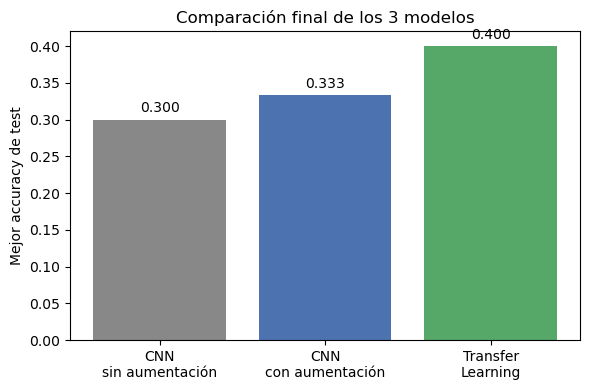

In [22]:
tl_best_test_acc = max(history_tl["test_acc"])
tl_overfit_gap = max(history_tl["train_acc"]) - tl_best_test_acc

print("Resumen final - mejor accuracy de test por modelo:")
print(f"  CNN desde cero (sin aumentación): {base_best_test_acc:.3f}")
print(f"  CNN desde cero (con aumentación): {aug_best_test_acc:.3f}")
print(f"  Transfer Learning (ResNet18):     {tl_best_test_acc:.3f}")
print()
print("Brecha train-test (overfitting) por modelo:")
print(f"  CNN desde cero (sin aumentación): {base_overfit_gap:.3f}")
print(f"  CNN desde cero (con aumentación): {aug_overfit_gap:.3f}")
print(f"  Transfer Learning (ResNet18):     {tl_overfit_gap:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
modelos = ["CNN\nsin aumentación", "CNN\ncon aumentación", "Transfer\nLearning"]
accs = [base_best_test_acc, aug_best_test_acc, tl_best_test_acc]
ax.bar(modelos, accs, color=["#888888", "#4C72B0", "#55A868"])
ax.set_ylabel("Mejor accuracy de test")
ax.set_title("Comparación final de los 3 modelos")
for i, v in enumerate(accs):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

**Conclusión.** Los tres modelos entrenados sobre el mismo split y los
mismos atributos dan una comparación clara:

| Modelo | Mejor accuracy de test | Brecha train-test |
|---|---|---|
| CNN desde cero (sin aumentación) | 0.300 | 0.690 |
| CNN desde cero (con aumentación) | 0.333 | 0.106 |
| **Transfer Learning (ResNet18)** | **0.400** | **0.089** |

El modelo con Transfer Learning no solo logra el mejor accuracy de los tres
(40.0%, contra 30.0%–33.3% de las CNN entrenadas desde cero), sino que
además lo hace con una brecha de overfitting tan baja como la del modelo
aumentado (0.089 vs. 0.106), a pesar de tener 11.2 millones de parámetros en
total. La razón es que solo 73,426 de esos parámetros son entrenables
(0.7% del total): el resto son los pesos de ResNet18 ya aprendidos en
ImageNet y permanecen congelados, por lo que el modelo no tiene forma de
memorizar el train set incluso si quisiera — solo puede ajustar una cabeza
pequeña sobre features visuales que ya son robustas (bordes, texturas,
formas generales).

El reporte de clasificación confirma que esta ventaja no es solo de
accuracy global: clases que con la CNN desde cero quedaban en f1=0.00
(`Dragon`, `Fighting`, `Fire`) mejoran notoriamente con Transfer Learning
(f1=0.50, 0.57 y 0.50 respectivamente), aunque otras como `Psychic` siguen
sin resolverse (f1=0.00 en ambos casos) — es un tipo sin una señal visual
clara y consistente, algo que ni las features de ImageNet logran capturar
bien a partir solo de la imagen y los 6 atributos numéricos.

**La conclusión principal de esta comparación es metodológica:** con un
dataset de ~500 imágenes para 17 clases con ejemplos, el cuello de botella
no es tanto la arquitectura de la CNN como la cantidad de datos disponible
para aprender features visuales desde cero. Reutilizar una red ya entrenada
en un dataset masivo (ImageNet) y solo adaptar la cabeza final es la
estrategia más efectiva de las tres probadas en este notebook, tanto en
accuracy como en resistencia al sobreajuste.